retrieval agents는 인덱스에서 데이터를 검색할지 여부에 대한 결정을 내릴 떄 유용
구현 llm에 검색 도구에 대한 접근 권한만 부여하면 됨

In [112]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community chromadb


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [113]:
import os
from uuid import uuid4

In [114]:
unique_id = uuid4().hex[0:8]
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = f'Agentic RAG- {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = ''
os.environ['OPENAI_API_KEY'] = ''

In [115]:
unique_id

'332cb398'

Retriever

In [116]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [117]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 100, chunk_overlap = 50
)
doc_splits = text_splitter.split_documents(docs_list)

vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name='rag-chroma',
    embedding=OpenAIEmbeddings(),
)
retriever = vectorstore.as_retriever()

retriever tool

In [118]:
from langchain_core.tools import create_retriever_tool

In [119]:
retriever_tool = create_retriever_tool(
    retriever,
    'retrieve_blog_posts',
    'Search ang return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.'
)

tools = [retriever_tool]

agent state

In [120]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [121]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

Nodes and Edges

### Usting Pydantic with langchain

In [122]:
from typing import Annotated, Sequence, Literal
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langgraph.prebuilt import tools_condition

In [123]:
def grade_documents(state) -> Literal['generate', 'rewrite']:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'" )

    model = ChatOpenAI(temperature=0, model='gpt-4o', streaming=True)

    llm_with_tool = model.with_structured_output(grade)

    prompt = PromptTemplate(
        template = """You are a grader assessing relevance of a retrieved document to user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document dontains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=['context', 'question'],
    )

    chain = prompt |llm_with_tool

    messages = state['messages']
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({'question': question, 'context': docs})

    score = scored_result.binary_score

    if score =='yes':
        print('---DECISION: DOCS RELEVANT---')
        return 'generate'
    else:
        print('---DECISION: DOCS NOT RELEVANT---')
        print(score)
        return 'rewrite'

In [124]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given the question, it will decide to retrieve using the retriever tool, or simplt end.
    
    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print('---CALL AGENT---')
    messages = state['messages']
    model = ChatOpenAI(temperature=0, streaming=True, model='gpt-4o')
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {'messages': [response]}

In [125]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """
    print('---TRANSFORM QUERY---')
    messages = state['messages']
    question = messages[0].content

    msg = [
        HumanMessage(
            content = f"""\n
    Look at the input and try to reason about the underlying semantic intent / meaning. \n
    Here is the initial question:
    \n ------- \n
    {question}
    \n ------- \n
    Formulate an improved question"""
        )
    ]

    model = ChatOpenAI(temperature=0, model='gpt-4o', streaming=True)
    response = model.invoke(msg)
    return {'messages': [response]}

In [126]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """
    print('---GENERATE---')
    messages = state['messages']
    question = messages[0].content
    last_messages = messages[-1]

    docs = last_messages.content
    prompt = ChatPromptTemplate.from_template("""
You are an assistant for question-answering tasks.
                                              
Use the retrieved dontext below to answer the question. 
If the answer is not in the conext, say you don't know.
                                              
Question: {question}
                                              
Context:
{context}
                                            
Answer:
""")
    llm = ChatOpenAI(model = 'gpt-4o-mini',temperature=0, streaming=True)
    rag_chain = prompt | llm| StrOutputParser()

    response = rag_chain.invoke({
        "question":question,
        "context": docs
    })
    return {'messages': [response]}

Graph

In [127]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [128]:
workflow = StateGraph(AgentState)

workflow.add_node('agent', agent)
retrieve = ToolNode([retriever_tool])
workflow.add_node('retrieve', retrieve)
workflow.add_node('rewrite', rewrite)
workflow.add_node('generate', generate)
workflow.add_edge(START, 'agent')

workflow.add_conditional_edges(
    'agent',
    tools_condition,
    {
        'tools': 'retrieve',
        END: END,
    },
)

workflow.add_conditional_edges(
    'retrieve',
    grade_documents,
)
workflow.add_edge('generate', END)
workflow.add_edge('rewrite', 'agent')

graph = workflow.compile()

In [129]:
from IPython.display import display, Image

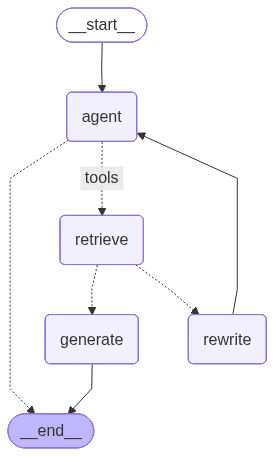

In [130]:
try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [131]:
import pprint

inputs = {
    "messages": [
        ("user", "What does Lilian Weng say about the types of agent memory?"),
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

---CALL AGENT---
"Output from node 'agent':"
'---'
{ 'messages': [ AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_b69b0233b8', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--019e0710-f668-7163-a0ae-2a70d1a7b7d5', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'types of agent memory'}, 'id': 'call_uve1Oirb0dTIjOczFm6AaYr2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 89, 'output_tokens': 18, 'total_tokens': 107, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}
'\n---\n'
---CHECK RELEVANCE---


c:\Users\compro\my\lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=grade(binary_score='yes'), input_type=grade])
  return self.__pydantic_serializer__.to_python(


---DECISION: DOCS RELEVANT---
"Output from node 'retrieve':"
'---'
{ 'messages': [ ToolMessage(content='Table of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three: Tool Use\n\nCase Studies\n\nScientific Discovery Agent\n\nGenerative Agents Simulation\n\nProof-of-Concept Examples\n\n\nChallenges\n\nCitation\n\nReferences\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three: Tool Use\n\nCase Studies\n\nScientific Discovery Agent\n\nGenerative Agents Simulation\n\nProof-of-Concept Examples\n\n\nChallenges\n\nCitation\n\nReferences\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent 